In [49]:
# # 1. Gỡ cài đặt các thư viện cũ
# !pip uninstall numpy pandas prophet cmdstanpy -y

# # 2. Cài đặt đúng phiên bản (theo project gốc)
# !pip install numpy==1.26.4
# !pip install pandas==2.2.2
# !pip install lightgbm==4.3.0 optuna==3.6.1 scikit-learn==1.5.1
# !pip install matplotlib==3.6.0 seaborn==0.13.2 shap==0.44.1
#!pip install streamlit==1.35.0 joblib==1.4.2 pyarrow==20.0.0
!pip install cmdstanpy
!pip install prophet
!pip install lightgbm
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 10.8 MB/s eta 0:00:00


In [50]:
import numpy as np
import pandas as pd
import prophet
import joblib
import os
import sys
import torch

if torch.cuda.is_available():
    print(f"GPU activated: {torch.cuda.get_device_name(0)}")
else:
    print(" still CPU")

print("NumPy version:", np.__version__)      # Phải là 1.26.4
print("Pandas version:", pd.__version__)     # Phải là 2.2.2
print("Prophet version:", prophet.__version__) # Phải là 1.1.4

 still CPU
NumPy version: 2.0.2
Pandas version: 2.2.2
Prophet version: 1.3.0


In [51]:

project_root = '/content/Walmart_sales_forecasting'
if project_root not in sys.path:
    sys.path.append(project_root)

print("Root:", project_root)

Root: /content/Walmart_sales_forecasting


In [52]:
import pandas as pd
import numpy as np
import torch
import prophet
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from src.metrics import weighted_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import joblib


In [53]:
%cd /content/Walmart_sales_forecasting
data_dir = 'data/processed/feature_engineering.feather'
df_feature = pd.read_feather(data_dir)
df_feature

/content/Walmart_sales_forecasting


,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,mean_sales_last_52_week,max_sales_last_52_week,min_sales_last_52_week,std_sales_last_52_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
6,1,1,2010-03-19,22136.64,151315,54.58,2.720,0.00,0.00,0.0,...,20183.157115,124418.65,-698.00,29776.749143,35820.081568,20227.707859,1472515.79,20451.608194,846686.47,18815.254889
149,1,2,2010-03-19,43615.49,151315,54.58,2.720,0.00,0.00,0.0,...,20273.734231,124418.65,-698.00,29775.363319,28978.360784,21659.406965,1472515.79,20451.608194,1848039.78,41067.550667
292,1,3,2010-03-19,9001.37,151315,54.58,2.720,0.00,0.00,0.0,...,21008.705962,124418.65,-698.00,29872.478944,36296.925392,38126.469241,1472515.79,20451.608194,371295.10,8251.002222
435,1,4,2010-03-19,34118.11,151315,54.58,2.720,0.00,0.00,0.0,...,20975.929423,124418.65,-698.00,29884.937600,22649.147696,16282.644810,1472515.79,20451.608194,1064848.12,23663.291556
578,1,5,2010-03-19,22632.57,151315,54.58,2.720,0.00,0.00,0.0,...,21480.558462,124418.65,-698.00,29880.969049,28383.628848,29659.243703,1472515.79,20451.608194,1063601.82,24734.926047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421012,45,93,2012-10-26,2487.80,118221,58.85,3.882,4018.91,58.08,100.0,...,9460.779808,54608.75,23.92,12025.307089,35354.118359,45312.322469,760281.43,11347.484030,1049693.34,24992.698571
421146,45,94,2012-10-26,5203.31,118221,58.85,3.882,4018.91,58.08,100.0,...,9309.340577,54608.75,23.92,12063.252477,18920.959180,13193.930617,760281.43,11347.484030,1291378.41,29349.509318
421289,45,95,2012-10-26,56017.47,118221,58.85,3.882,4018.91,58.08,100.0,...,9336.483462,54608.75,23.92,12052.177317,12062.134590,7200.965154,760281.43,11347.484030,3002617.27,66724.828222
421434,45,97,2012-10-26,6817.48,118221,58.85,3.882,4018.91,58.08,100.0,...,9909.124423,56017.47,23.92,13492.432928,34039.802295,43813.343789,760281.43,11347.484030,596563.70,13558.265909


In [54]:
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401996 entries, 6 to 421569
Data columns (total 53 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Store                    401996 non-null  category      
 1   Dept                     401996 non-null  category      
 2   Date                     401996 non-null  datetime64[ns]
 3   Weekly_Sales             401996 non-null  float64       
 4   Size                     401996 non-null  int64         
 5   Temperature              401996 non-null  float64       
 6   Fuel_Price               401996 non-null  float64       
 7   MarkDown1                401996 non-null  float64       
 8   MarkDown2                401996 non-null  float64       
 9   MarkDown3                401996 non-null  float64       
 10  MarkDown4                401996 non-null  float64       
 11  MarkDown5                401996 non-null  float64       
 12  CPI                  

# **Build Prophet**

In [109]:
test = df_feature[df_feature['is_test']]
train = df_feature[~df_feature['is_test']]

prophet_data = df_feature.groupby(['Date', 'store_dept']).agg(
    {
        'Weekly_Sales' : 'sum',
        'Size' : 'first',
        'Type_B': 'first',         
        'Type_C': 'first',
        'IsHoliday_True' : 'first',
        'Temperature': 'first',
        'Fuel_Price' : 'first',
        "total_markdown": "first",   
        "avg_markdown": "first",      
        "max_markdown": "first",
        'lags_2' : 'first',
        'lags_4' : 'first',
        'lags_6' : 'first',
        'mean_sales_last_2_week' : 'first',
        'mean_sales_last_4_week' : 'first',
        'mean_sales_last_6_week' : 'first',
    }
).reset_index()

# Giả sử IsHoliday_True là 0 hoặc 1, total_markdown là một số
prophet_data['holiday_markdown'] = prophet_data['IsHoliday_True'] * prophet_data['total_markdown']

prophet_data

,Date,store_dept,Weekly_Sales,Size,Type_B,Type_C,IsHoliday_True,Temperature,Fuel_Price,total_markdown,avg_markdown,max_markdown,lags_2,lags_4,lags_6,mean_sales_last_2_week,mean_sales_last_4_week,mean_sales_last_6_week,holiday_markdown
0,2011-02-04,store_10_dept_1,36145.83,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,30911.87,26041.71,140537.20,2745.320,22452.3400,23377.220000,0.0
1,2011-02-04,store_10_dept_10,43559.36,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,38277.23,43303.01,56874.92,75402.450,49673.0525,51088.651667,0.0
2,2011-02-04,store_10_dept_11,34892.54,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,27625.28,41213.41,41524.43,50683.840,58722.9475,49604.863333,0.0
3,2011-02-04,store_10_dept_12,8071.33,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,8052.11,6674.82,7185.88,39225.950,57314.2000,46190.685000,0.0
4,2011-02-04,store_10_dept_13,66266.75,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,63178.64,64917.14,57546.77,21481.935,36082.8875,46309.276667,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261078,2012-10-26,store_9_dept_91,914.84,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,698.84,998.95,1043.68,7728.250,6653.1025,6973.853333,0.0
261079,2012-10-26,store_9_dept_92,18310.28,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,20285.74,18333.69,18600.46,2005.805,4241.2575,5020.003333,0.0
261080,2012-10-26,store_9_dept_94,233.02,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,3.88,10.62,116.12,9612.560,8670.4050,7639.588333,0.0
261081,2012-10-26,store_9_dept_95,32382.05,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,32072.80,33119.87,34591.81,9271.650,5638.7275,5918.055000,0.0


In [110]:
#handle missing case
regressor_cols = ['Type_B', 'Type_C', 'IsHoliday_True', 'Temperature', 'Fuel_Price', 'total_markdown']
prophet_data[regressor_cols] = prophet_data[regressor_cols].fillna(0)

In [111]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [112]:
def build_prophet_model(prophet_data,  test_data, checkpoint_dir="/content/drive/MyDrive/Walmart_checkpoints"):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    min_test_time = test_data['Date'].min()
    max_test_time = test_data['Date'].max()
    
    prophet_model = {}
    prophet_predictions = {}
    prophet_metrics = pd.DataFrame(columns=['combo', 'mae', 'rmse', 'wape'])
    all_real = []
    all_predict = [] 
    
    scale_cols = ['Size', 'Temperature', 'Fuel_Price', 'total_markdown', 
                'lags_2', 'lags_4', 'lags_6',  
                'mean_sales_last_2_week', 'mean_sales_last_4_week', 'mean_sales_last_6_week',
                'holiday_markdown']
    
    for combination in prophet_data['store_dept'].unique():
        print(f'Build prophet model for {combination}')
        
        model_path = os.path.join(checkpoint_dir,f"{combination}_model.pkl")
        forecast_path = os.path.join(checkpoint_dir,f"{combination}_forecast.csv")
        scaler_path = os.path.join(checkpoint_dir, f"{combination}_scaler.pkl")
        
        if os.path.exists(model_path) and os.path.exists(forecast_path):
            print(f"Load existing {combination}")
            model = joblib.load(model_path)
            forecast = pd.read_csv(forecast_path, parse_dates=['ds'])
            scaler = joblib.load(scaler_path)
            prophet_model[combination] = model
            prophet_predictions[combination] = forecast
            
            # recalc metrics
            mae = mean_absolute_error(forecast['y'], forecast['yhat'])
            rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
            wape = weighted_absolute_percentage_error(forecast['y'], forecast['yhat'])
            prophet_metrics.loc[len(prophet_metrics)] = [combination, mae, rmse, wape]
            all_real.extend(forecast['y'])
            all_predict.extend(forecast['yhat'])
            continue
        
        combo = prophet_data[prophet_data['store_dept'] == combination].copy()
        combo = combo.rename(columns={'Date':'ds', 'Weekly_Sales' : 'y'}) #prophet require ds and y
        
        combo_train = combo[combo['ds'] < min_test_time]
        combo_test = combo[(combo['ds'] >= min_test_time) & (combo['ds'] <= max_test_time)]
        if combo_train.empty or combo_test.empty:
            print(f'Skip {combination} due to lack of data')
            continue
        
        # standardize value for model to learn
        available_cols = [col for col in scale_cols if col in combo_train.columns] 
        scaler = StandardScaler()
        if available_cols:
            scaler.fit(combo_train[available_cols])
            combo_train.loc[:, available_cols] = scaler.transform(combo_train[available_cols])
            combo_test.loc[:, available_cols] = scaler.transform(combo_test[available_cols])
        else:
            scaler = None
        
        # mulitplicative is not suitable for low sales due to being sensitive to changes
        if combo_train['y'].mean() < 50:
            model = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True, seasonality_mode='additive', changepoint_prior_scale=0.2, holidays_prior_scale=15.0)
        else:
            model = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True, seasonality_mode='multiplicative', changepoint_prior_scale=0.2, holidays_prior_scale=15.0)    
        
        #add regressor to learn
        regressors = ['Type_B', 'Type_C', 'IsHoliday_True'] + available_cols    
        for reg in regressors:
            if reg in combo_train.columns:
                model.add_regressor(reg)
        
        try:
            model.fit(combo_train)
        except Exception as e:
            print(f'Fail to train {combination} : {e}')
            continue
        
        # test
        future = combo_test[['ds'] + regressors]
        forecast = model.predict(future)
        
        forecast = forecast[['ds', 'yhat', 'yhat_upper', 'yhat_lower']].merge(combo_test[['ds', 'y']], on=['ds'])
        
        #save checkpoint
        joblib.dump(model, model_path)
        forecast.to_csv(forecast_path, index=False)
        if scaler is not None:
                    joblib.dump(scaler, scaler_path)
        print(f"Saved checkpoint for {combination}")
        
        prophet_model[combination] = model
        prophet_predictions[combination] = forecast
        
        # evaluate
        mae = mean_absolute_error(forecast['y'], forecast['yhat'])
        rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
        
        wampe = weighted_absolute_percentage_error(forecast['y'], forecast['yhat']).item()
        
        prophet_metrics.loc[len(prophet_metrics)] = [combination, mae, rmse, wampe]
        
        #overall evaluation
        all_real.extend(forecast['y'])
        all_predict.extend(forecast['yhat'])
        
    
    mean_mae = np.mean(prophet_metrics['mae'])
    mean_rmse = np.mean(prophet_metrics['rmse'])
    ovr_wampe = weighted_absolute_percentage_error(all_real, all_predict)
    
    return prophet_model, prophet_predictions, (mean_mae, mean_rmse, ovr_wampe)


prophet_model, prophet_predictions, (mean_mae, mean_rmse, ovr_wampe) = build_prophet_model(prophet_data, test)
    
        
    

Build prophet model for  store_10_dept_1
Saved checkpoint for  store_10_dept_1
Build prophet model for  store_10_dept_10
Saved checkpoint for  store_10_dept_10
Build prophet model for  store_10_dept_11
Saved checkpoint for  store_10_dept_11
Build prophet model for  store_10_dept_12
Saved checkpoint for  store_10_dept_12
Build prophet model for  store_10_dept_13
Saved checkpoint for  store_10_dept_13
Build prophet model for  store_10_dept_14
Saved checkpoint for  store_10_dept_14
Build prophet model for  store_10_dept_16
Saved checkpoint for  store_10_dept_16
Build prophet model for  store_10_dept_17
Saved checkpoint for  store_10_dept_17
Build prophet model for  store_10_dept_19
Saved checkpoint for  store_10_dept_19
Build prophet model for  store_10_dept_2
Saved checkpoint for  store_10_dept_2
Build prophet model for  store_10_dept_20
Saved checkpoint for  store_10_dept_20
Build prophet model for  store_10_dept_21
Saved checkpoint for  store_10_dept_21
Build prophet model for  store_1

INFO:prophet:n_changepoints greater than number of observations. Using 24.


Saved checkpoint for  store_33_dept_20
Build prophet model for  store_35_dept_51
Saved checkpoint for  store_35_dept_51
Build prophet model for  store_40_dept_48
Saved checkpoint for  store_40_dept_48
Build prophet model for  store_42_dept_31
Saved checkpoint for  store_42_dept_31
Build prophet model for  store_42_dept_74
Saved checkpoint for  store_42_dept_74
Build prophet model for  store_10_dept_98
Saved checkpoint for  store_10_dept_98
Build prophet model for  store_18_dept_94
Saved checkpoint for  store_18_dept_94
Build prophet model for  store_33_dept_59
Skip  store_33_dept_59 due to lack of data
Build prophet model for  store_36_dept_25


INFO:prophet:n_changepoints greater than number of observations. Using 13.


Saved checkpoint for  store_36_dept_25
Build prophet model for  store_39_dept_51


...

Saved checkpoint for  store_12_dept_49
Build prophet model for  store_38_dept_27


INFO:prophet:n_changepoints greater than number of observations. Using 0.


Saved checkpoint for  store_38_dept_27
Build prophet model for  store_44_dept_27


INFO:prophet:n_changepoints greater than number of observations. Using 0.


Saved checkpoint for  store_44_dept_27
Build prophet model for  store_9_dept_48
Saved checkpoint for  store_9_dept_48
Build prophet model for  store_33_dept_41
Fail to train  store_33_dept_41 : Dataframe has less than 2 non-NaN rows.
Build prophet model for  store_42_dept_20
Fail to train  store_42_dept_20 : Dataframe has less than 2 non-NaN rows.
Build prophet model for  store_31_dept_99
Skip  store_31_dept_99 due to lack of data
Build prophet model for  store_35_dept_49
Skip  store_35_dept_49 due to lack of data
Build prophet model for  store_16_dept_83
Skip  store_16_dept_83 due to lack of data
Build prophet model for  store_16_dept_93
Skip  store_16_dept_93 due to lack of data
Build prophet model for  store_5_dept_49
Skip  store_5_dept_49 due to lack of data
Build prophet model for  store_38_dept_26
Skip  store_38_dept_26 due to lack of data
Build prophet model for  store_38_dept_44
Skip  store_38_dept_44 due to lack of data
Build prophet model for  store_3_dept_49
Skip  store_3_de

In [113]:
print(
    f"Prophet Model Results:\nMAE: {mean_mae:.2f} | RMSE: {mean_rmse:.2f} | WAPE: {ovr_wampe:.2f}"
)

Prophet Model Results:
MAE: 7308.99 | RMSE: 8461.97 | WAPE: 0.46


In [ ]:
for combo, forecast in prophet_predictions.items():
    if forecast['yhat'].max() > forecast['y'].max() * 5:  # ngưỡng bất thường
        print(combo, forecast['yhat'].max(), forecast['y'].max())

In [114]:
%cd /content/drive/MyDrive/Walmart_checkpoints
!ls


/content/drive/MyDrive/Walmart_checkpoints


' store_10_dept_10_forecast.csv'  ' store_2_dept_24_forecast.csv'
' store_10_dept_10_model.pkl'	  ' store_2_dept_24_model.pkl'
' store_10_dept_10_scaler.pkl'	  ' store_2_dept_24_scaler.pkl'
' store_10_dept_11_forecast.csv'  ' store_2_dept_25_forecast.csv'
' store_10_dept_11_model.pkl'	  ' store_2_dept_25_model.pkl'
' store_10_dept_11_scaler.pkl'	  ' store_2_dept_25_scaler.pkl'
' store_10_dept_12_forecast.csv'  ' store_2_dept_26_forecast.csv'
' store_10_dept_12_model.pkl'	  ' store_2_dept_26_model.pkl'
' store_10_dept_12_scaler.pkl'	  ' store_2_dept_26_scaler.pkl'
' store_10_dept_13_forecast.csv'  ' store_2_dept_27_forecast.csv'
' store_10_dept_13_model.pkl'	  ' store_2_dept_27_model.pkl'
' store_10_dept_13_scaler.pkl'	  ' store_2_dept_27_scaler.pkl'
' store_10_dept_14_forecast.csv'  ' store_2_dept_28_forecast.csv'
' store_10_dept_14_model.pkl'	  ' store_2_dept_28_model.pkl'
' store_10_dept_14_scaler.pkl'	  ' store_2_dept_28_scaler.pkl'
' store_10_dept_16_forecast.csv'  ' store_2_dept_2

In [115]:
# Gộp tất cả dự báo thành một DataFrame
all_forecasts = pd.concat(prophet_predictions.values(), ignore_index=True)
print(all_forecasts.head())

          ds          yhat    yhat_upper   yhat_lower         y
0 2012-08-10  17973.971721  32277.960440  3328.156730  26320.29
1 2012-08-17  18556.465141  33231.505822  4435.081240  26752.40
2 2012-08-24  22946.351817  36428.668911  9588.123179  26804.84
3 2012-08-31  20077.678465  34047.356526  6154.032214  26083.28
4 2012-09-07  19784.983917  33658.444117  5348.141546  29426.33


In [116]:
import importlib
import src.plots
importlib.reload(src.plots)
from src.plots import visualize_pred, plot_prophet_comparison

df_prophet_pred = visualize_pred(prophet_predictions)
print(df_prophet_pred)

              ds          yhat    yhat_upper    yhat_lower         y  \
0     2012-08-10  17973.971721  32277.960440   3328.156730  26320.29   
1     2012-08-17  18556.465141  33231.505822   4435.081240  26752.40   
2     2012-08-24  22946.351817  36428.668911   9588.123179  26804.84   
3     2012-08-31  20077.678465  34047.356526   6154.032214  26083.28   
4     2012-09-07  19784.983917  33658.444117   5348.141546  29426.33   
...          ...           ...           ...           ...       ...   
34914 2012-09-28  18248.633963  18248.638211  18248.629647   1052.00   
34915 2012-10-05   4136.666998   4136.668058   4136.665914    597.00   
34916 2012-10-12  15396.323881  15396.328211  15396.319458   2227.00   
34917 2012-10-19   7699.862495   7699.864852   7699.860077    928.00   
34918 2012-10-26  17403.936089  17403.941894  17403.930151    654.00   

             store_dept  
0       store_10_dept_1  
1       store_10_dept_1  
2       store_10_dept_1  
3       store_10_dept_1  
4    

In [117]:
df_prophet_pred.groupby('store_dept').count().reset_index()
df_prophet_pred

In [118]:
plot_prophet_comparison(df_prophet_pred, store_dept='store_1_dept_10')

# **Build LightGBM**

In [55]:
cols_to_drop = ['Date', 'store_dept', 'Weekly_Sales', 'is_test'] # do not drop dept and store column so that model can learn unique pattern of specific ones

X_train = df_feature[~df_feature['is_test']].drop(cols_to_drop, axis=1)
y_train = df_feature[~df_feature['is_test']]['Weekly_Sales']
y_train_clipped = y_train.clip(lower=0)
y_train_log = np.log1p(y_train_clipped) # output are controlled by large sales -> log to reduce 

X_test = df_feature[df_feature['is_test']].drop(cols_to_drop, axis=1)
y_test = df_feature[df_feature['is_test']]['Weekly_Sales']

X_train


,Store,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,mean_sales_last_52_week,max_sales_last_52_week,min_sales_last_52_week,std_sales_last_52_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
6,1,1,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,20183.157115,124418.65,-698.00,29776.749143,35820.081568,20227.707859,1472515.79,20451.608194,846686.47,18815.254889
149,1,2,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,20273.734231,124418.65,-698.00,29775.363319,28978.360784,21659.406965,1472515.79,20451.608194,1848039.78,41067.550667
292,1,3,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,21008.705962,124418.65,-698.00,29872.478944,36296.925392,38126.469241,1472515.79,20451.608194,371295.10,8251.002222
435,1,4,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,20975.929423,124418.65,-698.00,29884.937600,22649.147696,16282.644810,1472515.79,20451.608194,1064848.12,23663.291556
578,1,5,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,21480.558462,124418.65,-698.00,29880.969049,28383.628848,29659.243703,1472515.79,20451.608194,1063601.82,24734.926047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421000,45,93,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,9023.586346,55100.78,-1.91,11959.182352,31767.816389,40144.232916,725729.51,10517.818986,1177581.75,28037.660714
421134,45,94,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,8559.113462,55100.78,-1.91,11687.992754,17626.748194,12650.318229,725729.51,10517.818986,1410974.73,35274.368250
421277,45,95,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,8435.615577,55100.78,-1.91,11696.696569,11052.484097,6521.244557,725729.51,10517.818986,3411164.17,75803.648222
421422,45,97,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,9126.529615,55100.78,-1.91,13181.244801,32005.307049,41348.908639,725729.51,10517.818986,671580.72,15263.198182


In [56]:
import lightgbm as lgbm
from sklearn.model_selection import TimeSeriesSplit

def build_lightgbm(X_train, y_train, X_test, y_test):
    print('Building LightGBM model...')
    
    tss = TimeSeriesSplit(n_splits=5)
    
    #default param of lgbm
    param = {
        'objective' : 'regression',
        'metric' : 'rmse',
        'boosting_type' : 'gbdt',
        'num_leaves' : 31,
        'learning_rate' : 0.1,
        'feature_fraction' : 0.9,
        'n_estimators' : 100,
        'verbose' : -1, 
    }
    
    model = lgbm.LGBMRegressor(**param)
    cr_val = []
    
    for train_idx, val_idx in tss.split(X_train):
        X_train_cv = X_train.iloc[train_idx]
        y_train_cv =  y_train.iloc[train_idx]
        X_val_cv = X_train.iloc[val_idx]
        y_val_cv = y_train.iloc[val_idx]
        
        model.fit(
            X_train_cv,
            y_train_cv,
            eval_set=[(X_val_cv, y_val_cv)],
            categorical_feature=['Store', 'Dept'],
        )
        
        pred = model.predict(X_val_cv) #invert log
        # y_val_cv_original = np.expm1(y_val_cv)
        
        mae = mean_absolute_error(y_val_cv, pred)
        rmse = np.sqrt(mean_squared_error(y_val_cv, pred))
        wape = weighted_absolute_percentage_error(y_val_cv, pred)
        
        cr_val.append((mae, rmse, wape))
        
    avg_mae, avg_rmse, avg_wape = np.mean(cr_val, axis=0)
    print(f'Model Result:\n MAE : {avg_mae} | RMSE : {avg_rmse} | WAPE : {avg_wape}')
    
    #Test model
    print('Building Test Model..')
    test_model = lgbm.LGBMRegressor(**param)
    test_model.fit(X_train, y_train)
    test_pred = test_model.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_wape = weighted_absolute_percentage_error(y_test, test_pred)
    df_test = df_feature[df_feature['is_test']].copy()
    df_test['y_true'] = y_test.values
    df_test['y_pred'] = test_pred
    df_test['error'] = np.abs(df_test['y_true'] - df_test['y_pred'])

    top_errors = df_test.sort_values('error', ascending=False).head(15)
    print(top_errors[['Date', 'Store', 'Dept', 'y_true', 'y_pred', 'error']])
    
    print(f'Test Model Result:\n MAE : {test_mae} | RMSE : {test_rmse} | WAPE : {test_wape}')
    
    return test_model, (test_mae, test_rmse, test_wape)
    
    
lgbm_model, (lgbm_mae, lgbm_rmse, lgbm_wape) = build_lightgbm(X_train, y_train, X_test, y_test)

Building LightGBM model...
Model Result:
 MAE : 1858.3420287148642 | RMSE : 4411.522921029164 | WAPE : 0.11534591957996147
Building Test Model..
             Date Store Dept     y_true         y_pred         error
149306 2012-10-19    16    9  111246.19   36394.239213  74851.950787
118027 2012-09-07    13    3  114230.60   48003.295924  66227.304076
87942  2012-08-17    10    3   60619.61  112743.592547  52123.982547
87944  2012-08-31    10    3   27278.21   75633.125019  48354.915019
87943  2012-08-24    10    3   40775.01   86009.629951  45234.619951
135764 2012-10-19    14   72   69389.31  112209.308797  42819.998797
137053 2012-08-24    14   90   85339.29  124715.680172  39376.390172
29938  2012-08-31     4    3   27826.14   66255.268474  38429.128474
118311 2012-08-24    13    5   73550.30   39262.074149  34288.225851
29939  2012-09-07     4    3   18714.18   52760.754233  34046.574233
118024 2012-08-17    13    3   61621.65   94731.959010  33110.309010
195187 2012-10-19    20   7

# **Finetune LightGBM**

In [57]:
import optuna
def optimizing_lgbm(X_train, y_train, X_test, y_test):
    
    print('Optimizing LightGBM with optuna..')
    
    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "num_leaves": trial.suggest_int("num_leaves", 15, 50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            "n_estimators": 1000,
            "verbose": -1,
        }
        
        model = lgbm.LGBMRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
        )
        pred = model.predict(X_test)
       
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        return rmse
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)
    
    best_params = study.best_params
    # best param only return the param found, not the fixed one so we have to add fixed param to match
    best_params.update(
        {
            'objective' : 'regression',
            'metric' : 'rmse',
            'boosting_type' : 'gbdt',
            'verbose' : -1,
        }
    )
    
    print(f'Best params:\n')
    for key, value in best_params.items():
        print(f'{key} : {value}')
        
    final_model = lgbm.LGBMRegressor(**best_params)
    final_model.fit(X_train, y_train)
    final_pred = final_model.predict(X_test)
    final_mae = mean_absolute_error(y_test, final_pred)
    final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
    final_wape = weighted_absolute_percentage_error(y_test, final_pred)
    
    print(f'Optimized LightGBM Model:\n MAE : {final_mae} | RMSE : {final_rmse} | WAPE : {final_wape}')
    
    return final_model, (final_mae, final_rmse, final_wape)


opt_model, (opt_mae, opt_rmse, opt_wape) = optimizing_lgbm(X_train, y_train, X_test, y_test)
    
    
    
    
    

[I 2026-08-16 15:37:22,061] A new study created in memory with name: no-name-8dc6ce32-34a2-4be6-80d0-01079a6679f0


Optimizing LightGBM with optuna..


[I 2026-08-16 15:38:07,158] Trial 0 finished with value: 2427.398060648471 and parameters: {'num_leaves': 24, 'learning_rate': 0.02428090843566895, 'feature_fraction': 0.8591459100752412, 'bagging_fraction': 0.7425241347111683, 'bagging_freq': 7, 'min_child_samples': 18}. Best is trial 0 with value: 2427.398060648471.
[I 2026-08-16 15:38:48,625] Trial 1 finished with value: 2381.177313530544 and parameters: {'num_leaves': 17, 'learning_rate': 0.04833232141488707, 'feature_fraction': 0.8593615504319927, 'bagging_fraction': 0.7250860798599789, 'bagging_freq': 4, 'min_child_samples': 22}. Best is trial 1 with value: 2381.177313530544.
[I 2026-08-16 15:39:29,733] Trial 2 finished with value: 2278.9715131451385 and parameters: {'num_leaves': 28, 'learning_rate': 0.053133376079618454, 'feature_fraction': 0.9936716161296506, 'bagging_fraction': 0.8678007606270567, 'bagging_freq': 1, 'min_child_samples': 29}. Best is trial 2 with value: 2278.9715131451385.
[I 2026-08-16 15:40:21,507] Trial 3 f

Best params:

num_leaves : 50
learning_rate : 0.09645961410588376
feature_fraction : 0.7184781423801022
bagging_fraction : 0.9348036408197478
bagging_freq : 6
min_child_samples : 6
objective : regression
metric : rmse
boosting_type : gbdt
verbose : -1
Optimized LightGBM Model:
 MAE : 1263.415828449649 | RMSE : 2468.7019014585558 | WAPE : 0.08096182957973114


In [58]:

import matplotlib.pyplot as plt
import seaborn as sns
def evaluate_model(model, X_test, y_test, data):
    """
    Evaluate the model performance on the test set (last 3 months of 2017)
    """
    print("\nEvaluating model performance on test set...")

    test_preds = model.predict(X_test)

    test_mae = mean_absolute_error(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_wape = weighted_absolute_percentage_error(y_test, test_preds)

    print(f"Final Model Test Evaluation:")
    print(f"    MAE: {test_mae:.2f}")
    print(f"    RMSE: {test_rmse:.2f}")
    print(f"    WAPE: {test_wape:.2f}%")

    # Analyze errors by time period (month)
    test_results = data[data["is_test"]].copy()
    test_results["prediction"] = test_preds
    test_results["error"] = test_results["Weekly_Sales"] - test_results["prediction"]
    test_results["abs_error"] = np.abs(test_results["error"])
    test_results["month_name"] = test_results["Date"].dt.strftime("%B")
    
    # Summarize errors by month
    monthly_errors = (
        test_results.groupby("month_name")
        .agg({"abs_error": "mean", "error": "mean", "Weekly_Sales": "mean"})
        .reset_index()
    )
    monthly_errors["error_pct"] = (
        100 * monthly_errors["abs_error"] / monthly_errors["Weekly_Sales"]
    )

    print("\nError Analysis by Month:")
    print(
        monthly_errors[["month_name", "abs_error", "error_pct"]].to_string(index=False)
    )

    # Include month and store information for granular analysis
    test_results["year_month"] = test_results["Date"].dt.strftime("%Y-%m")

    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, test_preds, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "r--")
    plt.title("Actual vs Predicted Sales (Test Set)")
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.tight_layout()
    plt.savefig('actual_vs_predicted_test.png')
    
    # Plot error distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(test_results["error"], kde=True)
    plt.title("Error Distribution")
    plt.xlabel("Prediction Error")
    plt.tight_layout()
    plt.savefig('error_distribution.png')

    return test_mae, test_rmse, test_wape, test_preds, y_test, test_results




Evaluating model performance on test set...
Final Model Test Evaluation:
    MAE: 1263.42
    RMSE: 2468.70
    WAPE: 0.08%

Error Analysis by Month:
month_name   abs_error  error_pct
    August 1280.111479   7.992383
   October 1199.732090   7.719194
 September 1310.542239   8.590382


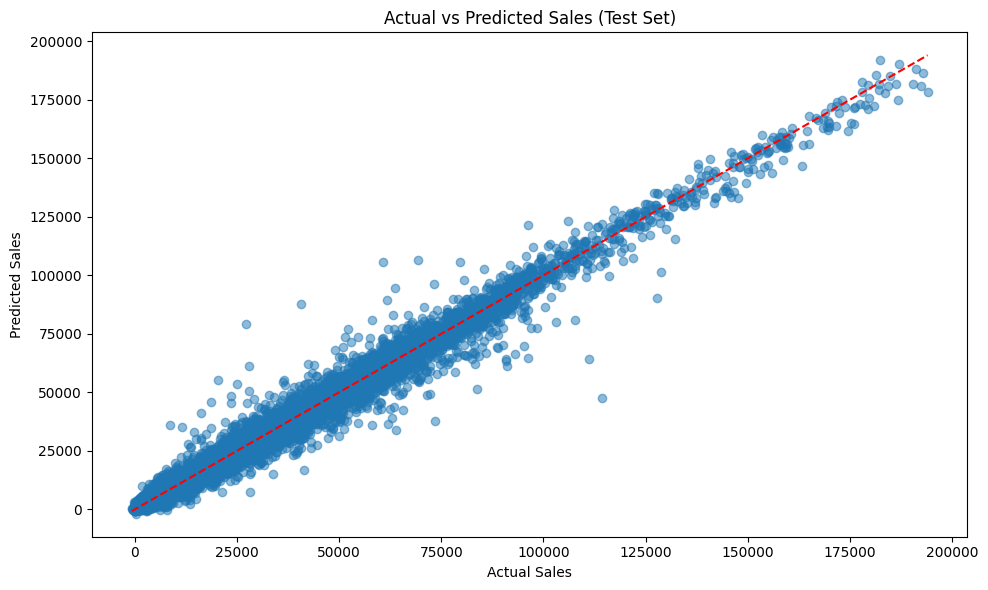

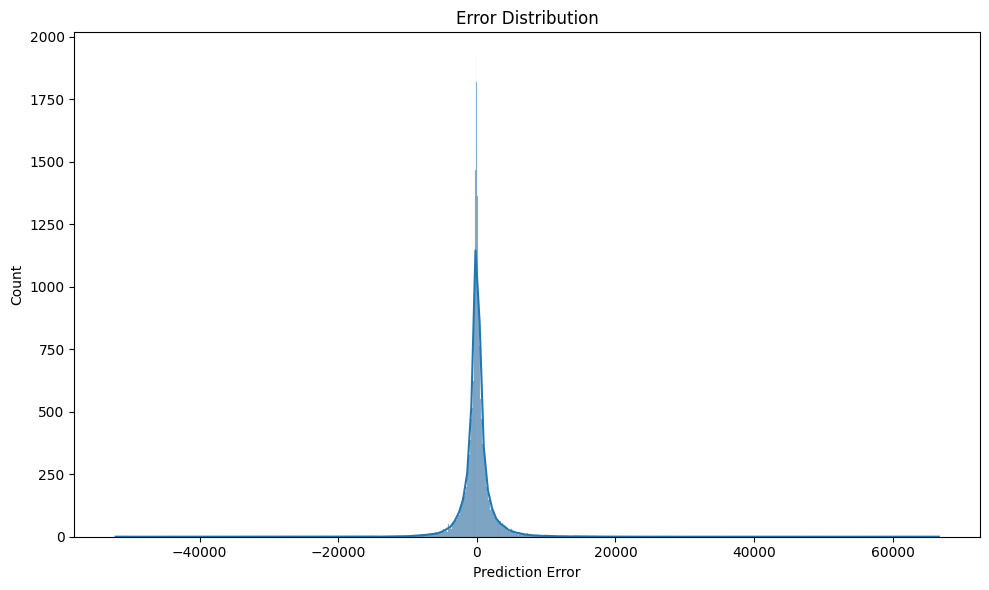

In [59]:
test_mae, test_rmse, test_smape, test_preds, y_test_values, test_results = (
    evaluate_model(opt_model, X_test, y_test, df_feature)
)

In [60]:
import os
import pickle
import json
import numpy as np
import pandas as pd

def save_lightgbm_model(model, X_train, output_dir="../models", model_version="1.0.0"):
    """
    Save LightGBM model and all necessary metadata for inference.
    
    Args:
        model: Trained LightGBM model
        X_train: DataFrame used for training (to extract feature names and dtypes)
        output_dir: Directory to save model artifacts
        model_version: Version string
    """
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving LightGBM model to: {os.path.abspath(output_dir)}")
    
    # 1. Save model
    model_path = os.path.join(output_dir, "sales_forecast_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"Model saved to {model_path}")

    # 2. Feature names and types
    feature_names = X_train.columns.tolist()
    feature_dtypes = X_train.dtypes.astype(str).to_dict()

    # 3. Build metadata
    feature_stats = {
        "model_version": model_version,
        "last_trained": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "required_columns": feature_names,
        "column_order": feature_names,
        "column_dtypes": feature_dtypes,
        "default_values": {
            "year": 2017,
            "month": 1,
            "day": 1,
            "day_of_week": 0,
            "is_weekend": 0,
            "quarter": 1,
            "is_holiday": 0,
            "Temperature": 60.0, 
            "Fuel_Price": 2.5,
            "CPI": 200.0,
            "Unemployment": 8.0,
            "total_markdown": 0.0,
            "avg_markdown": 0.0,
            "max_markdown": 0.0,
            "holiday_markdown": 0.0,
            # lag and rolling are not default because need to calc from the past
        },
        "temperature_bins": [-np.inf, 20, 25, 30, np.inf],
        "temperature_labels": ["Cold", "Cool", "Warm", "Hot"],
        "scalers": None  # save scaler
    }
    
    # if use StandardScaler
    if hasattr(model, 'scaler_'):
        scaler = model.scaler_  
        feature_stats["scalers"] = {
            "mean": scaler.mean_.tolist(),
            "scale": scaler.scale_.tolist()
        }

    # 4. Save metadata
    stats_pkl_path = os.path.join(output_dir, "feature_stats.pkl")
    with open(stats_pkl_path, "wb") as f:
        pickle.dump(feature_stats, f)
    print(f"Metadata (pickle) saved to {stats_pkl_path}")
    
    # 5. Save human-readable JSON version
    stats_json_path = os.path.join(output_dir, "feature_stats.json")
    # Convert numpy types to Python types for JSON serialization
    def convert_to_serializable(obj):
        if isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, pd.Timestamp):
            return str(obj)
        else:
            return obj

    with open(stats_json_path, "w") as f:
        json.dump(feature_stats, f, indent=2, default=convert_to_serializable)
    print(f"Metadata (JSON) saved to {stats_json_path}")

    print("Model and metadata saved successfully!")
    return model_path, stats_pkl_path

In [71]:
# Save model
drive_model_dir = "/content/drive/MyDrive/Walmart_sales_forecasting/artifacts/model"

save_lightgbm_model(
    model=opt_model,
    X_train=X_train,
    output_dir=drive_model_dir
)

Saving LightGBM model to: /content/drive/MyDrive/Walmart_sales_forecasting/artifacts/model
Model saved to /content/drive/MyDrive/Walmart_sales_forecasting/artifacts/model/sales_forecast_model.pkl
Metadata (pickle) saved to /content/drive/MyDrive/Walmart_sales_forecasting/artifacts/model/feature_stats.pkl
Metadata (JSON) saved to /content/drive/MyDrive/Walmart_sales_forecasting/artifacts/model/feature_stats.json
Model and metadata saved successfully!


('/content/drive/MyDrive/Walmart_sales_forecasting/artifacts/model/sales_forecast_model.pkl',
 '/content/drive/MyDrive/Walmart_sales_forecasting/artifacts/model/feature_stats.pkl')